# Utils

In [ ]:
def load_model(model, name):
    path = f"{Config.MODEL_DIR}/{name}.pth"
    model.load_state_dict(
        torch.load(path, map_location=Config.DEVICE)
    )
    return model

In [60]:
def save_fig(fig_name, folder=None, tight_layout=True, fig_extension="png", dpi=300):
    if folder:
        path = FIG_PATH / folder
        path.mkdir(exist_ok=True)
        filepath = path / f"{fig_name}.png"
    else:
        filepath = FIG_PATH / f"{fig_name}.png"
    
    if tight_layout:
        plt.tight_layout()
    print(f"saving {fig_name} at {filepath}")
    plt.savefig(filepath, format=fig_extension, dpi=dpi)

In [61]:
FIG_PATH = Path() / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

In [ ]:
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
WANDB_API_KEY = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=WANDB_API_KEY)

In [62]:
def find_best_thresholds(preds, targets):

    preds = torch.sigmoid(preds).cpu().numpy()
    targets = targets.cpu().numpy()

    thresholds = np.arange(0.05, 0.95, 0.01)

    best_thresholds = []

    for c in range(targets.shape[1]):

        best_f1 = 0
        best_t = 0.5

        for t in thresholds:

            binary = (preds[:,c] >= t).astype(int)

            f1 = f1_score(targets[:,c], binary)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        best_thresholds.append(best_t)

    return best_thresholds

In [ ]:
baseline_thresholds = find_best_thresholds(preds, targets)

baseline_thresholds_series = pd.Series({c: t for c, t in zip(Config.LABELS, baseline_thresholds)})
with open("baseline_thresholds_series", "wb") as f:
    pickle.dump(baseline_thresholds_series, f)

baseline_thresholds_series

In [ ]:
import pandas as pd

api = wandb.Api()

run = api.run("kyrillosnabil/nih-chest-pathologies/l7gdcu9o")

# Get all logged history
df = run.history()

print(df)

In [ ]:
runs = api.runs("kyrillosnabil/nih-chest-pathologies")

print(f"Found {len(runs)} runs")

In [ ]:
rows = []

for run in api.runs("kyrillosnabil/nih-chest-pathologies"):
    for row in run.scan_history(keys=["train_loss"]):
        rows.append({
            "run_id": run.id,
            "step": row.get("_step"),
            "train_loss": row.get("train_loss"),
        })

df = pd.DataFrame(rows)

# Gradcam issue

# Imports

In [63]:
import os
import json
import pickle
import random
import typing
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    densenet121,
    DenseNet121_Weights,
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

from tqdm.auto import tqdm

# Config

In [64]:
from dataclasses import dataclass

@dataclass
class Config:
    SEED = 42
    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    IMAGE_SIZE = 320
    NUM_CLASSES = 3
    LABELS = [
        "Atelectasis",
        "Effusion",
        "Pneumothorax"
    ]  
    BATCH_SIZE = 32
    NUM_WORKERS = 4 if DEVICE.type == "cuda" else 2
    PIN_MEMORY = DEVICE.type == "cuda"
    MODEL_NAME = "densenet121"
    DATA_DIR = Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data")
    ARTIFACT_DIR = Path(
        "/kaggle/input/datasets/shehabmahmoudhelmy/artifacts"
    )
    
    CHECKPOINT_PATH = Path(
        "/kaggle/input/models/kyrillosnabil/densenet121-xray-june/pytorch/default/1/final_densenet121_best.pt"
    )

In [ ]:
OUTPUT_DIR = Path("evaluation")

FIGURES_DIR = OUTPUT_DIR / "figures"

REPORT_DIR = OUTPUT_DIR / "reports"

CACHE_DIR = OUTPUT_DIR / "cache"

GRADCAM_DIR = OUTPUT_DIR / "gradcam"

for d in [
    OUTPUT_DIR,
    FIGURES_DIR,
    REPORT_DIR,
    CACHE_DIR,
    GRADCAM_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
WANDB_API_KEY = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=WANDB_API_KEY)

# Utils

In [ ]:
def set_seed(seed: int = Config.SEED):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

set_seed()

In [65]:
sns.set_theme(
    style="whitegrid",
    context="talk",
)

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
def save_figure(fig, name):

    png_path = FIGURES_DIR / f"{name}.png"

    pdf_path = FIGURES_DIR / f"{name}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    wandb.log({
        name: wandb.Image(str(png_path))
    })

In [ ]:
def save_fig(fig_name, folder=None, tight_layout=True, fig_extension="png", dpi=300):
    if folder:
        path = FIG_PATH / folder
        path.mkdir(exist_ok=True)
        filepath = path / f"{fig_name}.png"
    else:
        filepath = FIG_PATH / f"{fig_name}.png"
    
    if tight_layout:
        plt.tight_layout()
        
    plt.savefig(filepath, format=fig_extension, dpi=dpi)

In [ ]:
wandb.init(
    project="nih-chest-pathologies",
    job_type="evaluation",
    name="densenet121_evaluation"
)

# Core ML Components

# Pytorch Dataset

In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_index, target_labels, transform=None, is_xrv=False):
        self.df = df.reset_index(drop=True)
        self.image_index = image_index
        self.target_labels = target_labels
        self.transform = transform
        self.is_xrv = is_xrv
        self.image_names = self.df["Image Index"].values
        self.labels = self.df[self.target_labels].values.astype("float32")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = self.image_index[image_name]

        # Load grayscale image and convert to RGB
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise RuntimeError(f"Failed to load image: {image_path}")

        if not self.is_xrv:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        if self.transform:
            image = self.transform(image)

        label = torch.from_numpy(self.labels[idx])
        return image, label, image_name

# Transforms

In [66]:
def get_val_transforms(image_size):
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])


def get_test_transforms(image_size):
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

# DataLoader

In [ ]:
def create_eval_dataloader(df, image_index, split):

    is_xrv = Config.MODEL_NAME == "chexpert_densenet"

    transform = (
        get_xrv_val_transforms(Config.IMAGE_SIZE)
        if is_xrv
        else get_val_transforms(Config.IMAGE_SIZE)
    )
    
    dataset = ChestXrayDataset(
        df[df["split"] == split],
        image_index,
        Config.LABELS,
        transform=transform,
        is_xrv=is_xrv,
    )
    
    loader = DataLoader(
        dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        pin_memory=Config.PIN_MEMORY,
        num_workers=Config.NUM_WORKERS,
    )

    return loader

# Model Factory

In [67]:
def get_model(
    name: str,
    num_classes: int = 3,
    pretrained: bool = False
):

    if name == "resnet50":

        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = resnet50(weights=weights)

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )
        target_layer = model.layer4

    elif name == "densenet121":

        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = densenet121(weights=weights)

        model.classifier = nn.Linear(
            model.classifier.in_features,
            num_classes
        )
        
        target_layer = model.features.denseblock4

    elif name == "efficientnet_b0":

        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = efficientnet_b0(weights=weights)

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )

        target_layer = model.features[-1]

    elif name == "chexpert_densenet":
        
        model = xrv.models.DenseNet(weights="densenet121-res224-chex")
        model.classifier = nn.Linear(
            model.classifier.in_features,
            num_classes
        )

        target_layer = model.features.denseblock4
    
    else:
        raise ValueError("Unknown model")

    return model, target_layer

# Checkpoint Loader

In [68]:
def load_checkpoint(
    checkpoint_path: str | Path,
    model: nn.Module,
    device: torch.device,
):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    if "model_state_dict" in checkpoint:
        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

    else:
        model.load_state_dict(checkpoint)

    model.to(device)

    model.eval()

    print("=" * 60)
    print("Checkpoint Loaded")
    print("=" * 60)
    print(f"Epoch      : {checkpoint['epoch'] + 1}")
    print(f"Best AUC   : {checkpoint['best_auc']:.4f}")

    if "config" in checkpoint:

        print("Configuration")

        for k, v in checkpoint["config"].items():
            print(f"  {k}: {v}")

    return model, checkpoint

In [ ]:
@torch.inference_mode()
def run_inference(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
):

    model.eval()

    logits = []
    probabilities = []
    targets = []
    image_names = []

    for images, labels, names in tqdm(loader, desc="Running Inference"):
        images = images.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            enabled=device.type=="cuda"
        ):
            outputs = model(images)

        probs = torch.sigmoid(outputs)
        
        logits.append(outputs.cpu())
        probabilities.append(probs.cpu())
        targets.append(labels.cpu())
        
        image_names.extend(names)

    results = {
        "logits": torch.cat(logits),
        "probabilities": torch.cat(probabilities),
        "targets": torch.cat(targets),
        "image_names": image_names,
    }

    return results

In [ ]:
def save_predictions(results, filepath):
    torch.save(results, filepath)
    print(f"Saved predictions -> {filepath}")


def load_predictions(filepath):
    results = torch.load(filepath)
    print(f"Loaded predictions <- {filepath}")
    return results

# Metrics and Threshold Optimization

In [ ]:
def compute_auc(
    probabilities: torch.Tensor,
    targets: torch.Tensor,
):
    """
    Compute per-class and mean ROC-AUC.
    """

    probs = probabilities.cpu().numpy()
    labels = targets.cpu().numpy()

    auc_per_class = roc_auc_score(
        labels,
        probs,
        average=None,
    )

    mean_auc = float(np.mean(auc_per_class))

    return {
        "per_class": auc_per_class,
        "mean": mean_auc,
    }

In [ ]:
def compute_average_precision(
    probabilities,
    targets,
):

    probs = probabilities.cpu().numpy()
    labels = targets.cpu().numpy()

    ap = []

    for i in range(labels.shape[1]):

        ap.append(
            average_precision_score(
                labels[:, i],
                probs[:, i]
            )
        )

    ap = np.asarray(ap)

    return {
        "per_class": ap,
        "mean": float(ap.mean())
    }

In [ ]:
def compute_roc_curves(
    probabilities,
    targets,
):

    probs = probabilities.cpu().numpy()
    labels = targets.cpu().numpy()

    roc_data = {}

    for idx, disease in enumerate(Config.LABELS):

        fpr, tpr, thresholds = roc_curve(
            labels[:, idx],
            probs[:, idx]
        )

        roc_data[disease] = {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds": thresholds,
        }

    return roc_data

In [ ]:
def compute_pr_curves(
    probabilities,
    targets,
):

    probs = probabilities.cpu().numpy()
    labels = targets.cpu().numpy()

    pr_data = {}

    for idx, disease in enumerate(Config.LABELS):

        precision, recall, thresholds = precision_recall_curve(
            labels[:, idx],
            probs[:, idx]
        )

        pr_data[disease] = {
            "precision": precision,
            "recall": recall,
            "thresholds": thresholds,
        }

    return pr_data

In [ ]:
def optimize_thresholds(
    probabilities,
    targets,
):
    """
    Optimize thresholds using validation predictions.

    Returns
    -------
    dict
        {
            disease:
            {
                "f1": ...,
                "youden": ...
            }
        }
    """

    probs = probabilities.cpu().numpy()
    labels = targets.cpu().numpy()

    thresholds = {}

    for idx, disease in enumerate(Config.LABELS):

        precision, recall, pr_thresholds = precision_recall_curve(
            labels[:, idx],
            probs[:, idx]
        )

        f1_scores = (
            2 * precision * recall
        ) / (
            precision + recall + 1e-8
        )

        best_f1_idx = np.argmax(f1_scores[:-1])

        f1_threshold = pr_thresholds[best_f1_idx]

        fpr, tpr, roc_thresholds = roc_curve(
            labels[:, idx],
            probs[:, idx]
        )

        youden = tpr - fpr

        best_youden_idx = np.argmax(youden)

        youden_threshold = roc_thresholds[best_youden_idx]

        thresholds[disease] = {

            "f1": float(f1_threshold),

            "youden": float(youden_threshold),

        }

    return thresholds

In [ ]:
def compute_binary_metrics(
    probabilities,
    targets,
    thresholds,
):
    """
    Compute threshold-dependent metrics per class.

    Parameters
    ----------
    thresholds : dict
        {disease: threshold}
    """

    probs = probabilities.cpu().numpy()
    labels = targets.cpu().numpy()

    rows = []

    for idx, disease in enumerate(Config.LABELS):

        thr = thresholds[disease]

        preds = (probs[:, idx] >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            labels[:, idx],
            preds
        ).ravel()

        sensitivity = tp / (tp + fn + 1e-8)

        specificity = tn / (tn + fp + 1e-8)

        precision = precision_score(
            labels[:, idx],
            preds,
            zero_division=0,
        )

        recall = recall_score(
            labels[:, idx],
            preds,
            zero_division=0,
        )

        f1 = f1_score(
            labels[:, idx],
            preds,
            zero_division=0,
        )

        balanced_acc = balanced_accuracy_score(
            labels[:, idx],
            preds,
        )

        mcc = matthews_corrcoef(
            labels[:, idx],
            preds,
        )

        rows.append({

            "Disease": disease,

            "Threshold": thr,

            "Sensitivity": sensitivity,

            "Specificity": specificity,

            "Precision": precision,

            "Recall": recall,

            "F1": f1,

            "Balanced Accuracy": balanced_acc,

            "MCC": mcc,

            "TP": tp,

            "TN": tn,

            "FP": fp,

            "FN": fn,

        })

    return pd.DataFrame(rows)

# Model Evaluation

In [ ]:
model, target_layer = get_model(
    name=Config.MODEL_NAME,
    num_classes=len(Config.LABELS),
    pretrained=False,
)

checkpoint_path = (
    Config.CHECKPOINT_PATH 
)

model, checkpoint = load_checkpoint(
    checkpoint_path=checkpoint_path,
    model=model,
    device=Config.DEVICE,
)

In [ ]:
with open(
    Config.ARTIFACT_DIR / "prepared_df.pkl",
    "rb"
) as f:

    df = pickle.load(f)

with open(
    Config.ARTIFACT_DIR / "image_index.pkl",
    "rb"
) as f:

    image_index = pickle.load(f)

In [ ]:
val_loader = create_eval_dataloader(
    df=df,
    image_index=image_index,
    split="val",
)

test_loader = create_eval_dataloader(
    df=df,
    image_index=image_index,
    split="test",
)

print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

In [ ]:
val_results = run_inference(
    model=model,
    loader=val_loader,
    device=Config.DEVICE,
)

print("Validation inference complete.")
print(val_results["probabilities"].shape)

In [ ]:
val_auc = compute_auc(
    val_results["probabilities"],
    val_results["targets"],
)

val_ap = compute_average_precision(
    val_results["probabilities"],
    val_results["targets"],
)

print("Validation ROC AUC")

for disease, auc in zip(
    Config.LABELS,
    val_auc["per_class"]
):
    print(f"{disease:15s}: {auc:.4f}")

print(f"\nMean ROC AUC : {val_auc['mean']:.4f}")

print("\nAverage Precision")

for disease, ap in zip(
    Config.LABELS,
    val_ap["per_class"]
):
    print(f"{disease:15s}: {ap:.4f}")

In [ ]:
# ============================================================
# Threshold Optimization
# ============================================================

optimized = optimize_thresholds(
    val_results["probabilities"],
    val_results["targets"],
)

thresholds = {
    disease: values["youden"]
    for disease, values in optimized.items()
}

print("Selected Thresholds\n")

for disease, threshold in thresholds.items():
    print(f"{disease:15s}: {threshold:.3f}")

In [ ]:
precision, recall, thresholds = precision_recall_curve(...)

f1 = 2 * precision[:-1] * recall[:-1] / (
    precision[:-1] + recall[:-1] + 1e-8
)

best = np.argmax(f1)

print(f1[best])
print(thresholds[best])
print(precision[best])
print(recall[best])

In [ ]:
# testing
idx = np.argmax(f1)

for i in range(max(0, idx-5), min(len(thresholds), idx+6)):
    print(
        thresholds[i],
        precision[i],
        recall[i],
        f1[i]
    )

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve
import numpy as np
import pandas as pd


def optimize_thresholds(
    probabilities,
    targets,
):
    """
    Optimize per-class decision thresholds.

    Computes two operating points for each disease:

    1. Maximum F1 score
    2. Maximum Youden's J statistic

    Parameters
    ----------
    probabilities : torch.Tensor
        Sigmoid probabilities of shape (N, C).

    targets : torch.Tensor
        Binary ground-truth labels of shape (N, C).

    Returns
    -------
    dict
        {
            disease:
            {
                "f1": {
                    "threshold": ...,
                    "precision": ...,
                    "recall": ...,
                    "f1": ...
                },
                "youden": {
                    "threshold": ...,
                    "sensitivity": ...,
                    "specificity": ...,
                    "youden": ...
                }
            }
        }
    """

    probs = probabilities.cpu().numpy()
    labels = targets.cpu().numpy()

    results = {}

    for idx, disease in enumerate(Config.LABELS):

        # =====================================================
        # F1 Optimization
        # =====================================================

        precision, recall, pr_thresholds = precision_recall_curve(
            labels[:, idx],
            probs[:, idx]
        )

        precision = precision[:-1]
        recall = recall[:-1]

        f1_scores = (
            2 * precision * recall
        ) / (
            precision + recall + 1e-8
        )

        best_f1_idx = np.argmax(f1_scores)

        # =====================================================
        # Youden Optimization
        # =====================================================

        fpr, tpr, roc_thresholds = roc_curve(
            labels[:, idx],
            probs[:, idx]
        )

        specificity = 1.0 - fpr
        youden_scores = tpr - fpr

        best_youden_idx = np.argmax(youden_scores)

        # =====================================================
        # Store
        # =====================================================

        results[disease] = {

            "f1": {

                "threshold": float(
                    pr_thresholds[best_f1_idx]
                ),

                "precision": float(
                    precision[best_f1_idx]
                ),

                "recall": float(
                    recall[best_f1_idx]
                ),

                "f1": float(
                    f1_scores[best_f1_idx]
                ),
            },

            "youden": {

                "threshold": float(
                    roc_thresholds[best_youden_idx]
                ),

                "sensitivity": float(
                    tpr[best_youden_idx]
                ),

                "specificity": float(
                    specificity[best_youden_idx]
                ),

                "youden": float(
                    youden_scores[best_youden_idx]
                ),
            }
        }

    return results

In [ ]:
# ============================================================
# Threshold Optimization
# ============================================================

optimized = optimize_thresholds(
    val_results["probabilities"],
    val_results["targets"],
)

for disease, values in optimized.items():

    print("=" * 70)
    print(disease)

    print("\nF1 Optimum")
    print(f"Threshold : {values['f1']['threshold']:.4f}")
    print(f"Precision : {values['f1']['precision']:.4f}")
    print(f"Recall    : {values['f1']['recall']:.4f}")
    print(f"F1 Score  : {values['f1']['f1']:.4f}")

    print("\nYouden Optimum")
    print(f"Threshold   : {values['youden']['threshold']:.4f}")
    print(f"Sensitivity : {values['youden']['sensitivity']:.4f}")
    print(f"Specificity : {values['youden']['specificity']:.4f}")
    print(f"Youden J    : {values['youden']['youden']:.4f}")

print("=" * 70)

In [ ]:
#testing
optimized

In [ ]:
# ============================================================
# Test Inference
# ============================================================

test_results = run_inference(
    model=model,
    loader=test_loader,
    device=Config.DEVICE,
)

print("Test inference complete.")

In [ ]:
# ============================================================
# Test Metrics
# ============================================================

test_auc = compute_auc(
    test_results["probabilities"],
    test_results["targets"],
)

test_ap = compute_average_precision(
    test_results["probabilities"],
    test_results["targets"],
)

binary_metrics = compute_binary_metrics(
    test_results["probabilities"],
    test_results["targets"],
    thresholds,
)

display(binary_metrics)

In [ ]:
# testing
# ============================================================
# Test Metrics
# ============================================================

test_auc = compute_auc(
    test_results["probabilities"],
    test_results["targets"],
)

test_ap = compute_average_precision(
    test_results["probabilities"],
    test_results["targets"],
)

binary_metrics = compute_binary_metrics(
    test_results["probabilities"],
    test_results["targets"],
    thresholds,
)

display(binary_metrics)

In [ ]:
#testing
test_auc

In [ ]:
# ============================================================
# Save Evaluation Artifacts
# ============================================================

artifact_dir = (
    Config.RESULTS_DIR /
    Config.MODEL_NAME
)

artifact_dir.mkdir(
    parents=True,
    exist_ok=True,
)

save_predictions(
    val_results,
    artifact_dir / "validation_predictions.pt",
)

save_predictions(
    test_results,
    artifact_dir / "test_predictions.pt",
)

binary_metrics.to_csv(
    artifact_dir / "binary_metrics.csv",
    index=False,
)

pd.DataFrame(
    {
        "Disease": Config.LABELS,
        "ROC AUC": test_auc["per_class"],
        "Average Precision": test_ap["per_class"],
    }
).to_csv(
    artifact_dir / "summary_metrics.csv",
    index=False,
)

print("Evaluation artifacts saved.")

In [ ]:
checkpoint = torch.load(
    Config.MODEL_PATH,
    map_location=Config.DEVICE,
    weights_only=False
)

training_config = checkpoint["config"]

architecture = training_config["architecture"]
image_size = training_config["image_size"]
batch_size = training_config["batch_size"]

print("Loaded configuration:\n")

for k, v in training_config.items():
    print(f"{k:20s}: {v}")

In [ ]:
model = get_model(
    name=architecture,
    num_classes=Config.NUM_CLASSES
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(Config.DEVICE)
model.eval()

print(
    f"Checkpoint loaded successfully "
    f"(Best AUC = {checkpoint['best_auc']:.5f})"
)

In [ ]:
ARTIFACT_DIR = Path("/kaggle/input/datasets/shehabmahmoudhelmy/artifacts")
preprocessed_dataset_path = ARTIFACT_DIR / "prepared_df.pkl"

with open(preprocessed_dataset_path, "rb") as f:
    df = pickle.load(f)

image_index_path = ARTIFACT_DIR / "image_index.pkl"

with open(image_index_path, "rb") as f:
    image_index = pickle.load(f)


print(df.shape)
print(df["split"].value_counts())

In [ ]:
with open(
    Config.ARTIFACT_DIR / "prepared_df.pkl",
    "rb"
) as f:

    df = pickle.load(f)

with open(
    Config.ARTIFACT_DIR / "image_index.pkl",
    "rb"
) as f:

    image_index = pickle.load(f)

In [ ]:
api = wandb.Api()

run = api.run("kyrillosnabil/nih-chest-pathologies/l7gdcu9o")

best_config = {
    "backbone_lr": run.config["backbone_lr"],
    "head_lr": run.config["head_lr"],
    "gamma": run.config["gamma"],
    "alpha": run.config["alpha"],
    "batch_size": run.config["batch_size"],
    "image_size": run.config["image_size"],
    "weight_decay": run.config["weight_decay"]
}

pd.DataFrame(
    best_config.items(),
    columns=["Parameter", "Value"]
)

In [ ]:
_, val_loader, test_loader = create_dataloaders(
    df=df,
    image_index=image_index,
    target_labels=Config.LABELS,
    batch_size=best_config["batch_size"],
    image_size=best_config["image_size"],
    pin_memory=Config.PIN_MEMORY,
    num_workers=Config.NUM_WORKERS,
    model_arch="densenet121"
)

In [ ]:
checkpoint_path = "/kaggle/input/models/kyrillosnabil/densenet121-xray-june/pytorch/default/1/final_densenet121_best.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location=Config.DEVICE,
    weights_only=False
)

checkpoint.keys()

In [ ]:
saved_config = checkpoint["config"]

model = get_model(
    "densenet121",
    num_classes=3
).to(Config.DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

In [ ]:
print(
    f"Best Epoch: {checkpoint['epoch']}"
)

print(
    f"Best Validation AUC: "
    f"{checkpoint['best_auc']:.5f}"
)

In [ ]:
val_preds, val_targets = predict(
    model,
    val_loader,
    Config.DEVICE
)

In [ ]:
val_probs = torch.sigmoid(
    val_preds
).numpy()

val_targets_np = val_targets.numpy()

In [ ]:
class Config:

    SEED = 42
    IMAGE_SIZE = 320
    LABELS = [
        "Atelectasis",
        "Effusion",
        "Pneumothorax"
    ]
    NUM_CLASSES = len(LABELS)
    MODEL_ARCH = "resnet50"
    
    BATCH_SIZE = 32
    EPOCHS = 10
    LR = 1e-3
    MOMENTUM = 0.9
    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    NUM_WORKERS = 4 if DEVICE.type == "cuda" else 2
    PIN_MEMORY = DEVICE.type == "cuda"

    DATA_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
    CSV_PATH = os.path.join(
        DATA_DIR,
        "Data_Entry_2017.csv"
    )
    MODEL_DIR = "models"

# Utils

In [ ]:
def save_model(model, name):
    path = f"{Config.MODEL_DIR}/{name}.pth"
    torch.save(model.state_dict(), path)


def load_model(model, name):
    path = f"{Config.MODEL_DIR}/{name}.pth"
    model.load_state_dict(
        torch.load(path, map_location=Config.DEVICE)
    )
    return model

In [ ]:
FIG_PATH = Path() / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_name, folder=None, tight_layout=True, fig_extension="png", dpi=300):
    if folder:
        path = FIG_PATH / folder
        path.mkdir(exist_ok=True)
        filepath = path / f"{fig_name}.png"
    else:
        filepath = FIG_PATH / f"{fig_name}.png"
    
    if tight_layout:
        plt.tight_layout()
        
    plt.savefig(filepath, format=fig_extension, dpi=dpi)

# Pytorch dataset

# Transforms

In [ ]:
def get_train_transforms(size):

    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((size, size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225]
        )
    ])

In [ ]:
def get_val_transforms(size):

    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225]
        )
    ])

# Dataloaders

In [ ]:
def create_dataloaders(
    df,
    image_index,
    target_labels,
    batch_size,
    image_size,
    pin_memory,
    num_workers=4,
    model_arch=""
):

    is_xrv = model_arch == "chexpert_densenet"

    train_transform = get_xrv_train_transforms(image_size) if is_xrv else get_train_transforms(image_size)
    val_transform = get_xrv_val_transforms(image_size) if is_xrv else get_val_transforms(image_size)
    
    train_dataset = ChestXrayDataset(
        df[df["split"] == "train"],
        image_index,
        target_labels,
        transform=train_transform,
        is_xrv=is_xrv
    )
    
    val_dataset = ChestXrayDataset(
        df[df["split"] == "val"],
        image_index,
        target_labels,
        transform=val_transform,
        is_xrv=is_xrv
    )

    test_dataset = ChestXrayDataset(
        df[df["split"] == "test"],
        image_index,
        target_labels,
        transform=val_transform,
        is_xrv=is_xrv    
    )
        
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_memory,
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_memory,
        num_workers=num_workers
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_memory,
        num_workers=num_workers
    )

    
    return train_loader, val_loader, test_loader


# Model Factory

In [ ]:
def get_model(name, num_classes=3, pretrained=True):

    if name == "resnet50":

        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = resnet50(weights=weights)

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

    elif name == "densenet121":

        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = densenet121(weights=weights)

        model.classifier = nn.Linear(
            model.classifier.in_features,
            num_classes
        )

    elif name == "efficientnet_b0":

        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = efficientnet_b0(weights=weights)

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )

    elif name == "chexpert_densenet":
        
        model = xrv.models.DenseNet(weights="densenet121-res224-chex")
        model.classifier = nn.Linear(
            model.classifier.in_features,
            num_classes
        )
    
    else:
        raise ValueError("Unknown model")

    return model

# Optimizer Factory

In [ ]:
def get_optimizer(name, model, backbone_lr, head_lr, wd):

    head_name = "classifier"
    if isinstance(model, models.ResNet):
        head_name = "fc"

    backbone_params = []
    head_params = []

    for n, p in model.named_parameters():
        if head_name in n:
            head_params.append(p)
        else:
            backbone_params.append(p)

    param_groups = [
        {'params': backbone_params, 'lr': backbone_lr}, # Base learning rate for backbone
        {'params': head_params, 'lr': head_lr} # Faster learning for head
    ]
    
    if name == 'adamw':
        return torch.optim.AdamW(param_groups, weight_decay=wd)
    elif name == 'sgd':
        return torch.optim.SGD(param_groups, momentum=0.9, weight_decay=wd)
    elif name == 'rmsprop':
        return torch.optim.RMSprop(param_groups, weight_decay=wd)

# class FocalLoss(nn.Module):

In [ ]:
class FocalLoss(nn.Module):
    """
    Binary Focal Loss for imbalanced classification.
    Reference: 'Focal Loss for Dense Object Detection' (https://arxiv.org/abs/1708.02002)
    """
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = "mean"):
        """
        Args:
            alpha (float): Weighting factor for the positive class. 
                           Negative class weight is evaluated as (1 - alpha).
                           Set to a negative value to disable alpha weighting.
            gamma (float): Focusing parameter to down-weight easy examples.
            reduction (str): Specifies the reduction to apply to the output:
                             'none' | 'mean' | 'sum'.
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits (torch.Tensor): Raw, unnormalized scores from the model.
            targets (torch.Tensor): Binary targets (0 or 1), same shape as logits.
            
        Returns:
            torch.Tensor: Computed Focal Loss.
        """
        # Ensure targets are floats for BCE
        targets = targets.to(dtype=logits.dtype)
        
        # Calculate standard BCE with logits (numerically stable)
        bce_loss = F.binary_cross_entropy_with_logits(
            logits, 
            targets, 
            reduction="none"
        )
        
        # Calculate pt: probability of the true class
        pt = torch.exp(-bce_loss)
        
        # Standard focal loss formula
        focal_loss = (1 - pt) ** self.gamma * bce_loss
        
        # Apply alpha class-balancing
        if self.alpha >= 0:
            # alpha_t = alpha * y + (1 - alpha) * (1 - y)
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_loss = alpha_t * focal_loss

        # Apply reduction
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss

# Model Engine

In [ ]:
def train_one_epoch(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: typing.Callable,
    device: torch.device,
    scaler: torch.cuda.amp.GradScaler
) -> float:
    
    model.train()
    
    running_loss = 0.0
    total_samples = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type):
            outputs = model(images)
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size
        
        pbar.set_postfix(loss=loss.item())

    return running_loss / total_samples

In [ ]:
def validate(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    loss_fn: typing.Callable,
    device: torch.device
) -> typing.Tuple[float, torch.Tensor, torch.Tensor]:

    model.eval()
    
    running_loss = 0.0
    total_samples = 0
    
    preds = []
    targets = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type=device.type):
                outputs = model(images)
                loss = loss_fn(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            preds.append(outputs.detach().cpu())
            targets.append(labels.detach().cpu())

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    return running_loss / total_samples, preds, targets

In [ ]:
def predict(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device
):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            with torch.autocast(device_type=device.type):
                outputs = model(images)

            preds.append(outputs.cpu())
            targets.append(labels.cpu())

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    return preds, targets

# Compute AUC

In [ ]:
def compute_auc(preds: torch.Tensor, targets: torch.Tensor):
    
    preds = torch.sigmoid(preds).detach().cpu().numpy()
    targets = targets.detach().cpu().numpy()


    aucs = roc_auc_score(
        targets,
        preds,
        average=None  
    )
    return aucs

In [ ]:
def run(train_loader, val_loader):

    set_seed()
    model = get_model()
    model.to(Config.DEVICE)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=Config.LR,
        momentum=Config.MOMENTUM
    )
    loss_fn = nn.BCEWithLogitsLoss()
 
    best_auc = 0
    for epoch in range(Config.EPOCHS):

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn
        )

        val_loss, preds, targets = validate(
            model,
            val_loader,
            loss_fn
        )

        auc = compute_auc(preds, targets)

        mean_auc = auc.mean()

        print(f"\nEpoch {epoch}")
        print("Train Loss:", train_loss)
        print("Val Loss:", val_loss)
        print("AUC:", auc)
        print("Mean AUC:", mean_auc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["mean_auc"].append(mean_auc)
        
        if mean_auc > best_auc:
            best_auc = mean_auc
            save_model(model, f"baseline_densenet121_epoch{epoch}")

In [ ]:
FINAL_CONFIG = {
    "architecture": "densenet121",

    "image_size": 320,
    "batch_size": 32,

    "optimizer": "adamw",

    "backbone_lr": 8.971931734503725e-05,
    "head_lr": 5.903388345924983e-04,

    "weight_decay": 1e-4,

    "alpha": 0.75,
    "gamma": 2.0,

    "epochs": 10,
    "patience": 0,

    "seed": 42
}

In [ ]:
Config.MODEL_ARCH = FINAL_CONFIG["architecture"]
Config.IMAGE_SIZE = FINAL_CONFIG["image_size"]
Config.BATCH_SIZE = FINAL_CONFIG["batch_size"]
Config.SEED = FINAL_CONFIG["seed"]

set_seed(Config.SEED)

ARTIFACT_DIR = Path("/kaggle/input/datasets/shehabmahmoudhelmy/artifacts")
preprocessed_dataset_path = ARTIFACT_DIR / "prepared_df.pkl"
with open(preprocessed_dataset_path, "rb") as f:
    df = pickle.load(f)

image_index_path = ARTIFACT_DIR /"image_index.pkl"
with open(image_index_path, "rb") as f:
    image_index = pickle.load(f)
    
train_loader, val_loader = create_dataloaders(
    df=df,
    image_index=image_index,
    target_labels=Config.LABELS,
    batch_size=FINAL_CONFIG["batch_size"],
    image_size=FINAL_CONFIG["image_size"],
    pin_memory=Config.PIN_MEMORY,
    num_workers=Config.NUM_WORKERS,
    model_arch=Config.MODEL_ARCH
)

model_path = "/kaggle/input/models/kyrillosnabil/densenet121-xray-june/pytorch/default/1/final_densenet121_best.pt"
model = get_model("densenet121")
checkpoint = torch.load(
    model_path,
    map_location=Config.DEVICE,
    weights_only=False
)

if "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        f"Loaded checkpoint from epoch "
        f"{checkpoint.get('epoch', 'unknown')}"
    )

else:
    # backward compatibility
    model.load_state_dict(checkpoint)

loss_fn = FocalLoss(
    alpha=FINAL_CONFIG["alpha"],
    gamma=FINAL_CONFIG["gamma"]
)

val_loss, preds, targets = validate(
    model,
    val_loader,
    loss_fn,
    Config.DEVICE
)

val_auc = compute_auc(preds, targets)

print("Validation AUC per disease")
for disease, auc in zip(Config.LABELS, val_auc):
    print(f"{disease}: {auc:.4f}")

print("Mean Validation AUC:", val_auc.mean())

# Visualization

In [ ]:
# ============================================================
# ROC Curve
# ============================================================

def plot_roc_curves(
    roc_data,
    auc_scores,
    labels,
):

    fig, ax = plt.subplots(figsize=(8, 8))

    for disease in labels:

        ax.plot(
            roc_data[disease]["fpr"],
            roc_data[disease]["tpr"],
            linewidth=2,
            label=f"{disease} (AUC={auc_scores[disease]:.3f})",
        )

    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        linewidth=1,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    title="Receiver Operating Characteristic"
    ax.set_title(title)

    ax.legend()

    ax.grid(alpha=0.3)
    save_fig(title.lower().replace(" ", "_"), "model_evaluation")

    plt.tight_layout()

    return fig

In [ ]:
# ============================================================
# Precision-Recall Curves
# ============================================================

def plot_pr_curves(
    pr_data,
    ap_scores,
    labels,
):

    fig, ax = plt.subplots(figsize=(8, 8))

    for disease in labels:

        ax.plot(
            pr_data[disease]["recall"],
            pr_data[disease]["precision"],
            linewidth=2,
            label=f"{disease} (AP={ap_scores[disease]:.3f})",
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")

    title="Precision-Recall Curves"
    ax.set_title(title)

    ax.legend()

    ax.grid(alpha=0.3)

    plt.tight_layout()
    save_fig(title.lower().replace(" ", "_"), "model_evaluation")

    return fig

In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================
# from matplotlib.colors import LogNorm

def plot_confusion_matrix(
    cm,
    disease,
):

    fig, ax = plt.subplots(figsize=(5, 5))

    cm = cm.astype(float)
    cm = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm)

    # im = ax.imshow(
    #     cm,
    #     cmap="Blues",
    #     norm=LogNorm(vmin=1, vmax=cm.max())
    # )

    sns.heatmap(
        cm,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        cbar=True,
        square=True,
        linewidths=0.5,
        linecolor="white",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        annot_kws={
            "fontsize": 13,
            "fontweight": "bold",
        },
        ax=ax,
    )


    ax.set_title(disease + " Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # ax.set_xticks([0, 1])

    # ax.set_yticks([0, 1])

    # for i in range(2):
    #     for j in range(2):

    #         ax.text(
    #             j,
    #             i,
    #             cm[i, j],
    #             ha="center",
    #             va="center",
    #             fontsize=12,
    #         )

    # plt.colorbar(im)

    plt.tight_layout()
    save_fig(title.lower().replace(" ", "_"), "model_evaluation")

    
    return fig

In [ ]:
def plot_confusion_matrix(
    cm,
    disease,
):

    fig, ax = plt.subplots(figsize=(5, 5))

    im = ax.imshow(
        cm,
        cmap="Blues",
        interpolation="nearest",
    )

    ax.set_title(disease, fontsize=14)

    ax.set_xlabel("Predicted")

    ax.set_ylabel("True")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Negative", "Positive"])

    threshold = cm.max() / 2

    for i in range(2):
        for j in range(2):

            color = "white" if cm[i, j] > threshold else "black"

            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                color=color,
                fontsize=13,
                fontweight="bold",
            )

    fig.colorbar(im, ax=ax)

    plt.tight_layout()

    return fig

In [ ]:
# ============================================================
# Prediction Distribution
# ============================================================

def plot_probability_distribution(
    probabilities,
    targets,
    disease,
):

    idx = Config.LABELS.index(disease)

    probs = probabilities[:, idx].numpy()

    labels = targets[:, idx].numpy()

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        probs[labels == 0],
        bins=30,
        alpha=0.6,
        label="Negative",
    )

    ax.hist(
        probs[labels == 1],
        bins=30,
        alpha=0.6,
        label="Positive",
    )

    ax.set_xlabel("Predicted Probability")

    ax.set_ylabel("Count")

    ax.legend()

    ax.grid(alpha=0.3)

    plt.tight_layout()

    return fig

In [ ]:
roc_data = compute_roc_curves(
    test_results["probabilities"],
    test_results["targets"],
)

pr_data = compute_pr_curves(
    test_results["probabilities"],
    test_results["targets"],
)

auc_dict = dict(
    zip(
        Config.LABELS,
        test_auc["per_class"],
    )
)

ap_dict = dict(
    zip(
        Config.LABELS,
        test_ap["per_class"],
    )
)

roc_fig = plot_roc_curves(
    roc_data,
    auc_dict,
    Config.LABELS,
)

pr_fig = plot_pr_curves(
    pr_data,
    ap_dict,
    Config.LABELS,
)

In [ ]:
# testing
def plot_confusion_matrix(cm, disease):

    cm = np.asarray(cm)

    fmt = "d" if np.issubdtype(cm.dtype, np.integer) else ".0f"

    fig, ax = plt.subplots(figsize=(4, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        square=True,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=ax,
    )

    ax.set_title(disease)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    plt.tight_layout()

    return fig

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, disease):

    cm = np.asarray(cm)

    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Neg", "Pos"],
        yticklabels=["Neg", "Pos"],
        annot_kws={"size": 10},   # <-- smaller numbers
        cbar=True,
        square=True,
        ax=ax,
    )

    ax.set_title(disease, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)

    ax.tick_params(axis='both', labelsize=8)  # <-- smaller axis labels
   
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    save_fig(disease.lower().replace(" ", "_"), "model_evaluation")

    return fig

In [ ]:
for disease in Config.LABELS:

    idx = Config.LABELS.index(disease)

    preds = (
        test_results["probabilities"][:, idx].numpy()
        >= thresholds[disease]
    ).astype(int)

    cm = confusion_matrix(
        test_results["targets"][:, idx],
        preds,
    )

    fig = plot_confusion_matrix(
        cm,
        disease,
    )

    plt.show()

In [ ]:
for disease in Config.LABELS:

    fig = plot_probability_distribution(
        test_results["probabilities"],
        test_results["targets"],
        disease,
    )
    plt.title(disease)

    plt.show()

# Trying the final model with gradcam++

In [ ]:
def get_last_conv_layer(model):
    for module in reversed(list(model.modules())):
        if isinstance(module, torch.nn.Conv2d):
            return module

In [ ]:
image_index_path = "/kaggle/input/datasets/shehabmahmoudhelmy/artifacts/image_index.pkl"
with open(image_index_path, "rb") as f:
    image_index = pickle.load(f)

In [ ]:
df.columns

In [ ]:
atelectasis_images = df[ df["Atelectasis"] == 1].sample(100)["Image Index"].tolist()
effusion_images = df[ df["Effusion"] == 1].head(100)["Image Index"].tolist()
pneumo_images = df[ df["Pneumothorax"] == 1].sample(100)["Image Index"].tolist()

In [ ]:
healthy_imgs = df[df[["Pneumothorax", "Atelectasis", "Effusion"]].sum(axis=1)==0].sample(100)["Image Index"].tolist()

In [ ]:
pneumo_images

In [ ]:
df[df["Image Index"] == "00013993_001.png"]

In [ ]:
healthy_imgs

In [ ]:
img_name = "00000013_005.png"
image_path = image_index[img_name]

In [72]:
model_path = "/kaggle/input/models/kyrillosnabil/densenet121-xray-june/pytorch/default/1/final_densenet121_best.pt"
model, _ = get_model("densenet121")
checkpoint = torch.load(
    model_path,
    map_location=Config.DEVICE,
    weights_only=False
)

if "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        f"Loaded checkpoint from epoch "
        f"{checkpoint.get('epoch', 'unknown')}"
    )

else:
    # backward compatibility
    model.load_state_dict(checkpoint)

target_layer = get_last_conv_layer(model)

engine = VisionInferenceEngine(model, Config, [target_layer])


# for img_name in pneumo_images:
#     image_path = image_index[img_name]
#     engine.predict_and_visualize(image_path)

# engine.predict_and_visualize(image_path)

Loaded checkpoint from epoch 8


In [ ]:
for img in atelectasis_images:
    img_path = image_index[img]
    print(df[df["Image Index"] == img]["Finding Labels"] )
    engine.predict_and_visualize(img_path)

--- Inference Results for 00011835_002.png ---
here
sav
saving 00011835_002.png_36125    Atelectasis
Name: Finding Labels, dtype: object at figures/00011835_002.png_36125    Atelectasis
Name: Finding Labels, dtype: object.png
ed


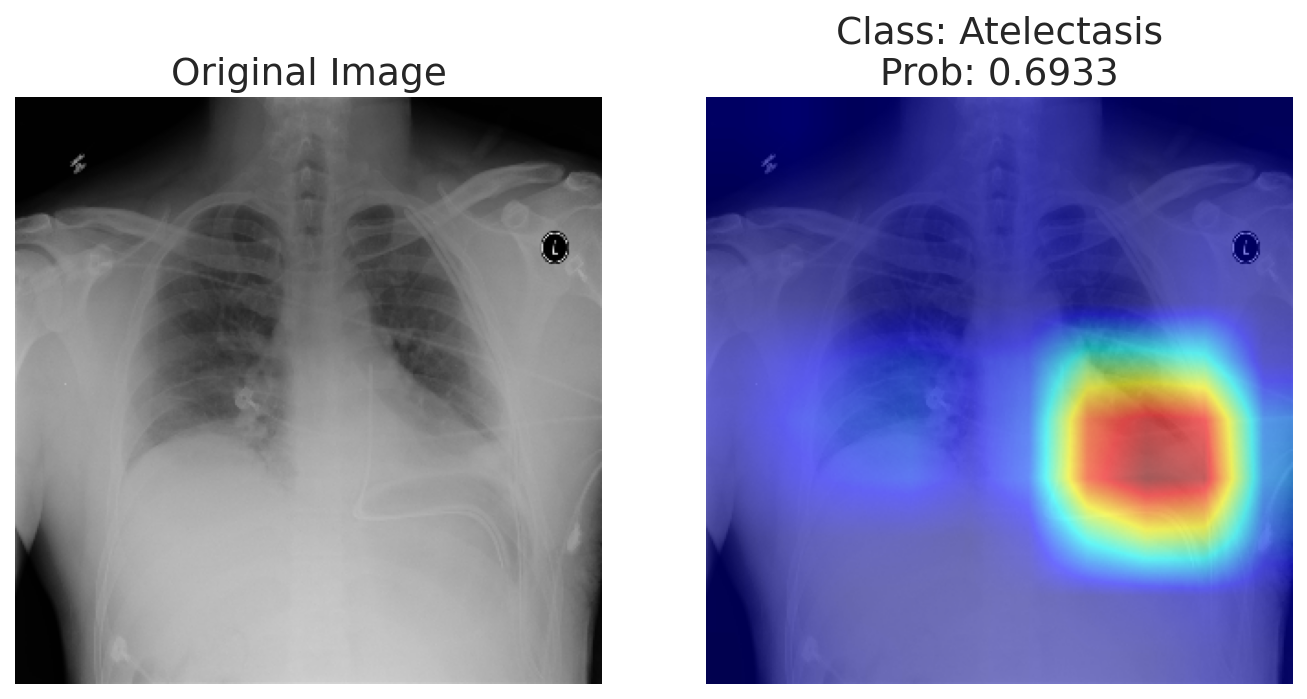

In [75]:
# engine = VisionInferenceEngine(model, Config, [target_layer])
img = "00011835_002.png"
img_path = image_index[img]
engine.predict_and_visualize(img_path)

In [70]:
!pip install grad-cam --quiet

In [71]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

class VisionInferenceEngine:
    def __init__(self, model, config, target_layers, thresholds=None):
        self.config = config
        self.device = config.DEVICE
        self.model = model.to(self.device).eval()
        self.labels = config.LABELS
        self.thresholds = thresholds if thresholds is not None else [0.5] * len(self.labels)
        
        # Initialize the Grad-CAM++ (generally more robust for multi-object)
        self.cam = GradCAMPlusPlus(model=self.model, target_layers=target_layers)
        
        # Preprocessing pipeline
        # self.transform = transforms.Compose([
        #     transforms.ToPILImage(),
        #     # transforms.Resize(self._get_tuple_size()),
        #     transforms.Resize(int(self._get_tuple_size()[0] * 1.14)),
        #     # transforms.Resize(int(self._get_tuple_size()[0] * 1.14))
        #     transforms.CenterCrop(self._get_tuple_size()),
        #     transforms.ToTensor(),
        #     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        # ])
        self.transform = transforms.Compose(
            [
                transforms.ToPILImage(),
                transforms.Resize((self.config.IMAGE_SIZE, self.config.IMAGE_SIZE)),
                transforms.CenterCrop(self.config.IMAGE_SIZE),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225],
                ),
            ]
        )


    def _get_tuple_size(self):
        """Ensures Config.IMAGE_SIZE is a tuple for transforms and OpenCV."""
        size = self.config.IMAGE_SIZE
        return (size, size) if isinstance(size, int) else size

    def preprocess_image(self, img_path):
        img = cv2.imread(img_path)
        if img is None: raise FileNotFoundError(f"Path invalid: {img_path}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensor = self.transform(img_rgb).unsqueeze(0).to(self.device)
        return tensor, img_rgb

    def predict_and_visualize(self, img_path, top_k=2):
        # 1. Inference
        img_tensor, original_rgb = self.preprocess_image(img_path)
        
        with torch.no_grad():
            logits = self.model(img_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()[0]

        # 2. Filter active detections (above threshold)
        active_indices = [i for i, p in enumerate(probs) if p >= self.thresholds[i]]
        
        # If nothing is above threshold, take the top prediction anyway for debugging
        if not active_indices:
            active_indices = [np.argmax(probs)]

        print(f"--- Inference Results for {img_path.split('/')[-1]} ---")
        
        # 3. Setup Visualization
        num_plots = len(active_indices[:top_k]) + 1
        fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
        if num_plots == 1: axes = [axes] # Handle single plot case

        # Show original resized image
        size = self._get_tuple_size()
        display_img = cv2.resize(original_rgb, (size[1], size[0]))
        axes[0].imshow(display_img)
        axes[0].set_title("Original Image")
        axes[0].axis('off')

        # 4. Generate Heatmaps for detected classes
        for idx, class_idx in enumerate(active_indices[:top_k]):
            targets = [ClassifierOutputTarget(class_idx)]
            
            # Generate CAM
            grayscale_cam = self.cam(input_tensor=img_tensor, targets=targets)[0, :]
            
            # Overlay
            # Note: show_cam_on_image expects image in range [0, 1]
            vis_img = np.float32(display_img) / 255
            overlay = show_cam_on_image(vis_img, grayscale_cam, use_rgb=True)
            
            ax = axes[idx + 1]
            ax.imshow(overlay)
            ax.set_title(f"Class: {self.labels[class_idx]}\nProb: {probs[class_idx]:.4f}")
            ax.axis('off')
            print("here")

        print("sav")
        save_fig(f"{img}_{df[df['Image Index'] == img]['Finding Labels']}")
        print("ed")
        plt.tight_layout()
        plt.show()

# ---------------------------------------------------------
# Execution Logic
# ---------------------------------------------------------

# 1. Identify Target Layer (e.g., last conv layer of a ResNet)
# If using ResNet: [model.layer4[-1]]
# # If using EfficientNet: [model.features[-1]]
# target_layer = get_last_conv_layer(model)

# # 2. Initialize Engine
# engine = VisionInferenceEngine(model, Config, [target_layer])

# # 3. Run on a sample from your loader
# sample_idx = 5
# img_id = val_loader.dataset.image_names[sample_idx]
# sample_path = val_loader.dataset.image_index[img_id]

# engine.predict_and_visualize(sample_path)